In [156]:
import os
import json
import joblib

import pandas as pd
import numpy as np


from scipy import sparse


from sklearn.svm import LinearSVC


from sklearn.model_selection import GridSearchCV


from sklearn.metrics import (

accuracy_score,

classification_report,

confusion_matrix,

precision_score,

recall_score,

f1_score

)


import matplotlib.pyplot as plt
import seaborn as sns

In [157]:
project_path="/content/drive/MyDrive/AI-Career-Assistant"


model_path=os.path.join(

project_path,

"models"

)

In [158]:
X_train=sparse.load_npz(

model_path+"/X_train.npz"

)


X_test=sparse.load_npz(

model_path+"/X_test.npz"

)

In [159]:
y_train=pd.read_csv(

model_path+"/y_train.csv"

).values.ravel()


y_test=pd.read_csv(

model_path+"/y_test.csv"

).values.ravel()

In [161]:
print(X_train.shape)
print(X_test.shape)

(132, 50000)
(34, 50000)


In [162]:
svm=LinearSVC(

    class_weight="balanced"

)

In [163]:
params={

"C":[0.5,1,2,3,5]

}


grid=GridSearchCV(

    svm,

    params,

    cv=5,

    scoring="accuracy"

)


grid.fit(

    X_train,

    y_train

)

GridSearchCV(cv=5, estimator=LinearSVC(class_weight='balanced'),
             param_grid={'C': [0.5, 1, 2, 3, 5]}, scoring='accuracy')

In [164]:
best_model=grid.best_estimator_


print(
grid.best_params_
)

{'C': 0.5}


In [165]:
y_pred=best_model.predict(

    X_test

)

In [166]:
accuracy=accuracy_score(

    y_test,

    y_pred

)


print(

"Accuracy:",

accuracy

)

Accuracy: 0.8823529411764706


In [167]:
print(

"Precision:",

precision_score(

y_test,

y_pred,

average="weighted"

)

)

Precision: 0.8112745098039216


In [168]:
print(

"Recall:",

recall_score(

y_test,

y_pred,

average="weighted"

)

)

Recall: 0.8823529411764706


In [169]:
print(

"F1:",

f1_score(

y_test,

y_pred,

average="weighted"

)

)

F1: 0.8383753501400559


In [170]:
print(

classification_report(

y_test,

y_pred

)

)

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         2
                     Arts       1.00      1.00      1.00         1
       Automation Testing       0.50      1.00      0.67         1
               Blockchain       1.00      1.00      1.00         1
         Business Analyst       1.00      1.00      1.00         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       1.00      1.00      1.00         2
                 Database       1.00      1.00      1.00         2
          DevOps Engineer       1.00      1.00      1.00         1
         DotNet Developer       0.67      1.00      0.80         2
            ETL Developer       1.00      1.00      1.00         1
   Electrical Engineering       1.00      1.00      1.00         1
                       HR       1.00      1.00      1.00         2
                   Hadoop       1.00      1.00      1.00     

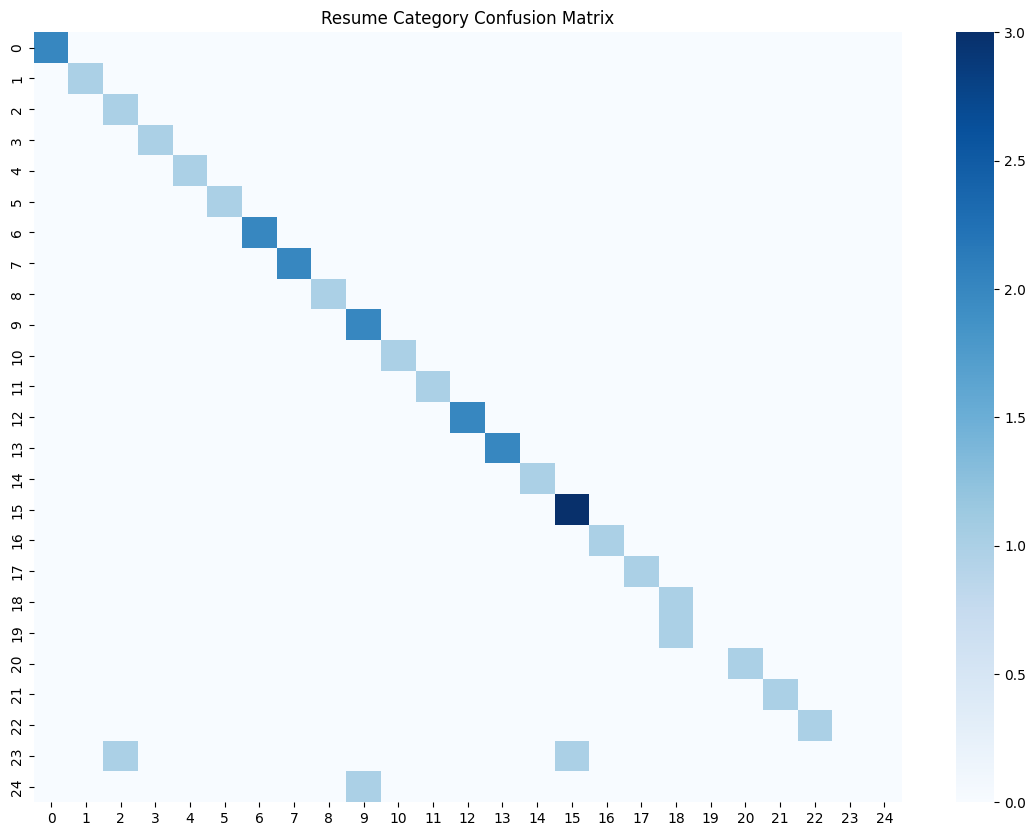

In [171]:
cm=confusion_matrix(

y_test,

y_pred

)


plt.figure(

figsize=(14,10)

)


sns.heatmap(

cm,

cmap="Blues"

)


plt.title(

"Resume Category Confusion Matrix"

)


plt.show()

In [172]:
joblib.dump(

best_model,

model_path+"/career_classifier.pkl"

)

['/content/drive/MyDrive/AI-Career-Assistant/models/career_classifier.pkl']

In [173]:
info={

"model":"LinearSVC",

"best_parameter":str(grid.best_params_),

"accuracy":float(accuracy),

"features":50000

}


with open(

model_path+"/model_info.json",

"w"

) as f:

    json.dump(

        info,

        f,

        indent=4

    )

In [174]:
tfidf=joblib.load(

model_path+"/tfidf_vectorizer.pkl"

)


model=joblib.load(

model_path+"/career_classifier.pkl"

)

In [175]:
resume="""

python developer

machine learning

tensorflow

sql

pandas

numpy

aws

"""

In [176]:
vector=tfidf.transform(

[resume]

)

In [177]:
prediction=model.predict(

vector

)


print(
prediction[0]
)

Python Developer


In [178]:
!git status

Refresh index: 100% (23/23), done.
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   data/processed/clean_resume.csv
	modified:   models/X_test.npz
	modified:   models/X_train.npz
	modified:   models/career_classifier.pkl
	modified:   models/model_info.json
	modified:   models/tfidf_vectorizer.pkl
	modified:   notebooks/03_Data_Cleaning_NLP.ipynb
	modified:   notebooks/05_Feature_Engineering.ipynb
	modified:   notebooks/06_Model_Training.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [179]:
!git add .

In [180]:
!git commit -m "Completed Phase 3 preprocessing, Phase 5 feature engineering, and Phase 6 model training"

[main 2857ffa] Completed Phase 3 preprocessing, Phase 5 feature engineering, and Phase 6 model training
 9 files changed, 176 insertions(+), 171 deletions(-)
 rewrite data/processed/clean_resume.csv (90%)
 rewrite models/X_test.npz (99%)
 rewrite models/X_train.npz (95%)
 rewrite models/career_classifier.pkl (63%)
 rewrite models/tfidf_vectorizer.pkl (73%)
 rewrite notebooks/03_Data_Cleaning_NLP.ipynb (98%)
 rewrite notebooks/05_Feature_Engineering.ipynb (98%)
 rewrite notebooks/06_Model_Training.ipynb (98%)


In [181]:
!git push origin main

Enumerating objects: 29, done.
Counting objects: 100% (29/29), done.
Delta compression using up to 2 threads
Compressing objects: 100% (15/15), done.
Writing objects: 100% (15/15), 3.85 MiB | 3.33 MiB/s, done.
Total 15 (delta 6), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (6/6), completed with 6 local objects.
To https://github.com/SURYAPANDI-M/AI-Career-Assistant.git
   6ed901a..2857ffa  main -> main


In [182]:
!git status

On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/06_Model_Training.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [183]:
!git add notebooks/06_Model_Training.ipynb

In [184]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   notebooks/06_Model_Training.ipynb

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/06_Model_Training.ipynb



In [185]:
!git commit -m "Updated Phase 6 model training and evaluation"

[main 4bf05fb] Updated Phase 6 model training and evaluation
 1 file changed, 1 insertion(+), 1 deletion(-)


In [186]:
!git push origin main

Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 1.84 KiB | 188.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/SURYAPANDI-M/AI-Career-Assistant.git
   2857ffa..4bf05fb  main -> main


In [187]:
!git status

On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/06_Model_Training.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [188]:
!git add notebooks/06_Model_Training.ipynb

In [189]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   notebooks/06_Model_Training.ipynb

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/06_Model_Training.ipynb



In [190]:
!git check-ignore -v notebooks/06_Model_Training.ipynb

In [191]:
!git diff -- notebooks/06_Model_Training.ipynb | head -50

diff --git a/notebooks/06_Model_Training.ipynb b/notebooks/06_Model_Training.ipynb
index 620545d..445141d 100644
--- a/notebooks/06_Model_Training.ipynb
+++ b/notebooks/06_Model_Training.ipynb
@@ -1 +1 @@
-{"nbformat":4,"nbformat_minor":0,"metadata":{"colab":{"provenance":[],"mount_file_id":"1x-kMcpFPAHKpnI-GGXGd55fb8AslRPBF","authorship_tag":"ABX9TyMDpElubX3v64B27FcUvZ18"},"kernelspec":{"name":"python3","display_name":"Python 3"},"language_info":{"name":"python"}},"cells":[{"cell_type":"code","source":["import os\n","import json\n","import joblib\n","\n","import pandas as pd\n","import numpy as np\n","\n","\n","from scipy import sparse\n","\n","\n","from sklearn.svm import LinearSVC\n","\n","\n","from sklearn.model_selection import GridSearchCV\n","\n","\n","from sklearn.metrics import (\n","\n","accuracy_score,\n","\n","classification_report,\n","\n","confusion_matrix,\n","\n","precision_score,\n","\n","recall_score,\n","\n","f1_score\n","\n",")\n","\n","\n","import matplotlib.pyplot

In [192]:
!git ls-files notebooks/06_Model_Training.ipynb

notebooks/06_Model_Training.ipynb


In [193]:
!git add notebooks/06_Model_Training.ipynb

In [194]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   notebooks/06_Model_Training.ipynb

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/06_Model_Training.ipynb



In [195]:
!git add notebooks/06_Model_Training.ipynb

In [196]:
!git status

On branch main
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   notebooks/06_Model_Training.ipynb



In [197]:
!git commit -m "Updated Phase 6 model training and evaluation"

[main bb17435] Updated Phase 6 model training and evaluation
 1 file changed, 1 insertion(+), 1 deletion(-)


In [198]:
!git push origin main

Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 109.87 KiB | 2.24 MiB/s, done.
Total 4 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/SURYAPANDI-M/AI-Career-Assistant.git
   4bf05fb..bb17435  main -> main


In [199]:
!git status

On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/06_Model_Training.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
